In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 설치 (필요할 때만) + import + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요. polars가 이번 노트북의 새 도구입니다.
!pip install numpy pandas polars matplotlib seaborn psutil -q

import os
import gc
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("polars :", pl.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy  : 2.4.6
pandas : 3.0.3
polars : 1.42.1


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 오늘 쓸 데이터를 한 번에 준비합니다.
# (이번에는 일부러 크게 만듭니다. 메모리 한계가 슬슬 보이도록.)
# ─────────────────────────────────────────────
np.random.seed(42)

DATA_DIR = Path("./moodumarket_big")
DATA_DIR.mkdir(exist_ok=True)

# 1) 고객(customers) — 5만 명
n_customers = 50_000
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(6)}" for i in range(1, n_customers + 1)],
    "age": np.clip(np.random.normal(35, 9, n_customers).round(), 14, 80).astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(
        ["서울", "경기", "부산", "인천", "대구", "광주", "대전", "기타"], n_customers
    ),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.7, 0.25, 0.05]),
})

# 2) 상품(products) — 1천 종
n_products = 1_000
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(5)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(["패션", "뷰티", "식품", "가전", "도서"], n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 20만 건
n_orders = 200_000
orders = pd.DataFrame({
    "order_id": np.arange(1, n_orders + 1),
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_id": np.random.choice(products["product_id"], n_orders),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n_orders),
    "amount": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_orders).astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.45, 0.55]),
    "order_date": pd.to_datetime("2025-01-01")
                  + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D"),
})

# 4) 웹 로그(web_logs) — 50만 건 (오늘의 주인공)
n_logs = 500_000
web_logs = pd.DataFrame({
    "log_id": np.arange(1, n_logs + 1),
    "ts": pd.to_datetime("2025-04-01")
          + pd.to_timedelta(np.random.randint(0, 86400 * 30, n_logs), unit="s"),
    "user_id": np.random.choice(customers["customer_id"], n_logs),
    "session_id": np.random.randint(1, 80_000, n_logs),
    "page": np.random.choice(
        ["home", "list", "detail", "cart", "checkout", "mypage", "search"],
        n_logs,
        p=[0.30, 0.25, 0.20, 0.10, 0.05, 0.05, 0.05],
    ),
    "device": np.random.choice(["mobile", "desktop", "tablet"], n_logs, p=[0.70, 0.25, 0.05]),
    "status_code": np.random.choice([200, 200, 200, 200, 304, 404, 500], n_logs),
    "response_ms": np.clip(np.random.gamma(2.0, 80, n_logs), 5, 5000).round().astype(int),
    "bytes_sent": np.random.randint(500, 200_000, n_logs),
})

# CSV로 저장해두면 청크 처리·Polars 입출력 비교 시 같은 파일을 함께 씁니다.
orders_csv = DATA_DIR / "orders.csv"
logs_csv = DATA_DIR / "web_logs.csv"
orders.to_csv(orders_csv, index=False)
web_logs.to_csv(logs_csv, index=False)

print("모두마켓 데이터 생성 완료")
print(f"  customers : {customers.shape}")
print(f"  products  : {products.shape}")
print(f"  orders    : {orders.shape}  →  {orders_csv} ({orders_csv.stat().st_size/1024/1024:.1f} MB)")
print(f"  web_logs  : {web_logs.shape}  →  {logs_csv} ({logs_csv.stat().st_size/1024/1024:.1f} MB)")

모두마켓 데이터 생성 완료
  customers : (50000, 5)
  products  : (1000, 3)
  orders    : (200000, 7)  →  moodumarket_big\orders.csv (9.0 MB)
  web_logs  : (500000, 9)  →  moodumarket_big\web_logs.csv (32.8 MB)


In [3]:
# 예제 1: df.info(memory_usage='deep')로 자료형과 메모리를 함께 본다.
print("=== web_logs.info() — 자료형 + 메모리 ===")
web_logs.info(memory_usage="deep")

=== web_logs.info() — 자료형 + 메모리 ===
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   log_id       500000 non-null  int64         
 1   ts           500000 non-null  datetime64[us]
 2   user_id      500000 non-null  str           
 3   session_id   500000 non-null  int32         
 4   page         500000 non-null  str           
 5   device       500000 non-null  str           
 6   status_code  500000 non-null  int64         
 7   response_ms  500000 non-null  int64         
 8   bytes_sent   500000 non-null  int32         
dtypes: datetime64[us](1), int32(2), int64(3), str(3)
memory usage: 39.1 MB


In [4]:
# 예제 2: 컬럼별 메모리 사용량을 따져 보고 어디서 크게 먹는지 확인합니다.
mem = web_logs.memory_usage(deep=True).sort_values(ascending=False)
mem_mb = (mem / 1024 / 1024).round(2)

print("=== 컬럼별 메모리 (MB) ===")
print(mem_mb.to_string())
print(f"\n→ 총합: {mem_mb.sum():.2f} MB")

=== 컬럼별 메모리 (MB) ===
user_id        7.15
device         6.80
page           6.10
log_id         3.81
response_ms    3.81
ts             3.81
status_code    3.81
session_id     1.91
bytes_sent     1.91
Index          0.00

→ 총합: 39.11 MB


In [5]:
# 예제 3: psutil로 노트북 전체 메모리를 측정 — DataFrame 하나가 아닌 '지금 이 프로세스'.
try:
    import psutil
    proc = psutil.Process(os.getpid())
    rss_mb = proc.memory_info().rss / 1024 / 1024
    print(f"현재 노트북 프로세스 메모리 사용량(RSS): {rss_mb:.1f} MB")
    print("→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.")
except ImportError:
    print("psutil 미설치 — `!pip install psutil` 로 설치하면 노트북 전체 메모리도 볼 수 있어요.")

현재 노트북 프로세스 메모리 사용량(RSS): 298.3 MB
→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.


In [6]:
# 예제 4: '필터링이 사본을 만든다'는 사실을 RSS 변화로 확인합니다.
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

before = rss_mb()

# 사본을 일부러 5개 만든다 — 실제 분석에서도 이런 일이 줄줄이 일어납니다.
copies = []
for _ in range(5):
    copies.append(web_logs[web_logs["status_code"] == 200].copy())

after = rss_mb()
print(f"사본 만들기 전 RSS : {before:.1f} MB")
print(f"사본 5개 만든 후 RSS: {after:.1f} MB")
print(f"증가량               : {after - before:+.1f} MB")

# 청소: 사본 제거 → 가비지 컬렉션
del copies
gc.collect()
print(f"사본 제거 후 RSS    : {rss_mb():.1f} MB  (즉시 다 안 줄어도 정상입니다)")

사본 만들기 전 RSS : 298.4 MB
사본 5개 만든 후 RSS: 418.7 MB
증가량               : +120.3 MB
사본 제거 후 RSS    : 353.2 MB  (즉시 다 안 줄어도 정상입니다)


In [7]:
# 모범 답안 — 직접 해본 다음 비교하세요.
orders_small = orders.copy()
orders_small["order_id"] = orders_small["order_id"].astype("int32")
orders_small["quantity"] = orders_small["quantity"].astype("int8")
orders_small["channel"] = orders_small["channel"].astype("category")
orders_small["amount"] = orders_small["amount"].astype("float32")

b = orders.memory_usage(deep=True).sum() / 1024 / 1024
a = orders_small.memory_usage(deep=True).sum() / 1024 / 1024
print(f"Before: {b:.2f} MB")
print(f"After : {a:.2f} MB")
print(f"절감   : {(1 - a / b) * 100:.1f}%")

Before: 13.73 MB
After : 8.96 MB
절감   : 34.7%


In [8]:
# 예제 1: (A) 통째로 — 페이지별 평균 응답 시간 계산 + 메모리 측정
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

# 통째로 읽고 집계
gc.collect()
before = rss_mb()
t0 = time.perf_counter()

full = pd.read_csv(logs_csv, parse_dates=["ts"])
result_full = full.groupby("page")["response_ms"].mean().round(2)

elapsed_full = time.perf_counter() - t0
peak_full = rss_mb() - before

del full
gc.collect()

print("=== 통째로 읽기 ===")
print(f"소요 시간: {elapsed_full:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_full:.1f} MB")
print()
print(result_full)

=== 통째로 읽기 ===
소요 시간:  0.95 초
메모리 증가량(피크 근사): 1.6 MB

page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [9]:
# 예제 2: (B) 청크로 — 같은 결과를 청크 단위로 계산하고 합치기
# 각 청크에서 (page별 합계, 개수)를 모은 다음 마지막에 합 ÷ 개수.

gc.collect()
before = rss_mb()
t0 = time.perf_counter()

CHUNK = 50_000
sum_per_page = {}
cnt_per_page = {}

for chunk in pd.read_csv(logs_csv, chunksize=CHUNK,
                          dtype={"page": "category", "device": "category"},
                          parse_dates=["ts"]):
    grouped = chunk.groupby("page", observed=True)["response_ms"].agg(["sum", "count"])
    for page, row in grouped.iterrows():
        sum_per_page[page] = sum_per_page.get(page, 0) + row["sum"]
        cnt_per_page[page] = cnt_per_page.get(page, 0) + row["count"]

# reduce: 합 ÷ 개수
result_chunk = pd.Series({
    page: sum_per_page[page] / cnt_per_page[page]
    for page in sum_per_page
}).round(2).sort_index()

elapsed_chunk = time.perf_counter() - t0
peak_chunk = rss_mb() - before

print("=== 청크로 읽기 ===")
print(f"청크 크기: {CHUNK:,}행")
print(f"소요 시간: {elapsed_chunk:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_chunk:.1f} MB")
print()
print(result_chunk)

=== 청크로 읽기 ===
청크 크기: 50,000행
소요 시간:  1.25 초
메모리 증가량(피크 근사): -19.0 MB

cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
dtype: float64


In [10]:
# 스스로 해보자! ✏️
# 1. logs_csv를 chunksize=50_000으로 청크 처리하세요.
# 2. device(mobile/desktop/tablet)별 평균 response_ms를 구하세요.
# 3. 결과를 정렬해서 출력하세요.

for chunk in pd.read_csv("logs_csv", chunksize = 50_000):
    device = chunk.groupby("mobile")

# 여기에 코드를 작성하세요

FileNotFoundError: [Errno 2] No such file or directory: 'logs_csv'

In [ ]:
# 예제 2: (B) 청크로 — 같은 결과를 청크 단위로 계산하고 합치기
# 각 청크에서 (page별 합계, 개수)를 모은 다음 마지막에 합 ÷ 개수.

gc.collect()
before = rss_mb()
t0 = time.perf_counter()

CHUNK = 50_000
sum_per_page = {}
cnt_per_page = {}

for chunk in pd.read_csv(logs_csv, chunksize=CHUNK,
                          dtype={"page": "category", "device": "category"},
                          parse_dates=["ts"]):
    grouped = chunk.groupby("page", observed=True)["response_ms"].agg(["sum", "count"])
    for page, row in grouped.iterrows():
        sum_per_page[page] = sum_per_page.get(page, 0) + row["sum"]
        cnt_per_page[page] = cnt_per_page.get(page, 0) + row["count"]

# reduce: 합 ÷ 개수
result_chunk = pd.Series({
    page: sum_per_page[page] / cnt_per_page[page]
    for page in sum_per_page
}).round(2).sort_index()

elapsed_chunk = time.perf_counter() - t0
peak_chunk = rss_mb() - before

print("=== 청크로 읽기 ===")
print(f"청크 크기: {CHUNK:,}행")
print(f"소요 시간: {elapsed_chunk:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_chunk:.1f} MB")
print()
print(result_chunk)

In [ ]:
# ─────────────────────────────────────────────
# [도식] 통째로 vs 청크 — 시간/메모리 막대그래프
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

methods = ["Full load", "Chunked"]
times = [elapsed_full, elapsed_chunk]
peaks = [peak_full, peak_chunk]

axes[0].bar(methods, times, color=["#4C72B0", "#55A868"])
axes[0].set_title("Time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

axes[1].bar(methods, peaks, color=["#4C72B0", "#55A868"])
axes[1].set_title("Memory increase (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [ ]:
# 모범 답안 — 직접 해본 다음 비교하세요.
sum_dev = {}
cnt_dev = {}
for chunk in pd.read_csv(logs_csv, chunksize=50_000):
    g = chunk.groupby("device")["response_ms"].agg(["sum", "count"])
    for dev, row in g.iterrows():
        sum_dev[dev] = sum_dev.get(dev, 0) + row["sum"]
        cnt_dev[dev] = cnt_dev.get(dev, 0) + row["count"]

result_dev = pd.Series({d: sum_dev[d] / cnt_dev[d] for d in sum_dev}).round(2)
print(result_dev.sort_values())

In [ ]:
chunk.head()

In [ ]:
# 예제 1: Polars로 CSV 읽기 — pl.read_csv
t0 = time.perf_counter()
logs_pl = pl.read_csv(logs_csv, try_parse_dates=True)
elapsed_pl = time.perf_counter() - t0

# pandas와 같은 작업: 시간 측정용
t0 = time.perf_counter()
logs_pd = pd.read_csv(logs_csv, parse_dates=["ts"])
elapsed_pd = time.perf_counter() - t0

print(f"Polars pl.read_csv : {elapsed_pl:.2f} 초   shape = {logs_pl.shape}")
print(f"pandas pd.read_csv : {elapsed_pd:.2f} 초   shape = {logs_pd.shape}")
print()
print("=== Polars head ===")
print(logs_pl.head())

In [ ]:
# 예제 2: 같은 작업을 Polars로 — 페이지별 평균 응답 시간
t0 = time.perf_counter()
result_pl = (
    logs_pl
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .sort("page")
)
elapsed_pl = time.perf_counter() - t0

t0 = time.perf_counter()
result_pd = logs_pd.groupby("page")["response_ms"].mean().sort_index().round(2)
elapsed_pd = time.perf_counter() - t0

print(f"Polars group_by + mean : {elapsed_pl*1000:.1f} ms")
print(f"pandas groupby  + mean : {elapsed_pd*1000:.1f} ms")
print()
print("=== Polars 결과 ===")
print(result_pl)

In [ ]:
# 모범 답안 — 직접 해본 다음 비교하세요.
ans = (
    logs_pl
    .group_by("device")
    .agg(pl.col("bytes_sent").sum().alias("total_bytes"))
    .sort("total_bytes", descending=True)
)
print(ans)

In [ ]:
# 예제 1: eager 방식 — 한 줄씩 즉시 실행
t0 = time.perf_counter()
result_eager = (
    pl.read_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
)
elapsed_eager = time.perf_counter() - t0

print(f"Eager  : {elapsed_eager*1000:6.1f} ms")
print(result_eager)

In [ ]:
# 예제 2: lazy 방식 — scan_csv로 계획만, 마지막에 collect()
t0 = time.perf_counter()
result_lazy = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
    .collect()
)
elapsed_lazy = time.perf_counter() - t0

print(f"Lazy   : {elapsed_lazy*1000:6.1f} ms")
print(result_lazy)

In [ ]:
# 예제 3: Polars가 어떤 계획을 세웠는지 확인 — .explain()
plan = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .explain()
)
print(plan)

In [ ]:
# 모범 답안 — 직접 해본 다음 비교하세요.
error_summary = (
    pl.scan_csv(logs_csv)
    .filter(pl.col("status_code") >= 400)
    .group_by("page")
    .agg(pl.len().alias("n_errors"))
    .sort("n_errors", descending=True)
    .collect()
)
print(error_summary)

In [ ]:
# 벤치마크 유틸 — 같은 작업을 N회 돌려 평균 시간을 측정
def benchmark(label, func, n=3):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    avg_ms = sum(times) / n * 1000
    print(f"{label:24s}: {avg_ms:7.1f} ms   (n={n}, min={min(times)*1000:.1f}ms)")
    return avg_ms

# 측정 대상 함수들 — Q1: 페이지별 평균 응답 시간
def q1_pandas():
    return (
        pd.read_csv(logs_csv)
        .groupby("page")["response_ms"].mean()
    )

def q1_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
    )

def q1_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
        .collect()
    )

print("=== Q1: 페이지별 평균 응답 시간 ===")
q1_pd = benchmark("pandas",        q1_pandas)
q1_pe = benchmark("polars (eager)", q1_polars_eager)
q1_pl = benchmark("polars (lazy)",  q1_polars_lazy)

In [ ]:
# Q2: 디바이스별 bytes_sent 합계
def q2_pandas():
    return pd.read_csv(logs_csv).groupby("device")["bytes_sent"].sum()

def q2_polars_eager():
    return pl.read_csv(logs_csv).group_by("device").agg(pl.col("bytes_sent").sum())

def q2_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("device")
        .agg(pl.col("bytes_sent").sum())
        .collect()
    )

print("=== Q2: 디바이스별 bytes_sent 합계 ===")
q2_pd = benchmark("pandas",        q2_pandas)
q2_pe = benchmark("polars (eager)", q2_polars_eager)
q2_pl = benchmark("polars (lazy)",  q2_polars_lazy)

In [ ]:
# Q3: status_code >= 400 페이지별 에러 수 (필터 + 집계 → pushdown 유리)
def q3_pandas():
    df = pd.read_csv(logs_csv)
    return df[df["status_code"] >= 400].groupby("page").size()

def q3_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
    )

def q3_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
        .collect()
    )

print("=== Q3: status_code>=400 페이지별 에러 수 ===")
q3_pd = benchmark("pandas",        q3_pandas)
q3_pe = benchmark("polars (eager)", q3_polars_eager)
q3_pl = benchmark("polars (lazy)",  q3_polars_lazy)

In [ ]:
# Q4: 페이지별 응답 시간의 중앙값 (정렬 필요, pandas 약점)
def q4_pandas():
    return pd.read_csv(logs_csv).groupby("page")["response_ms"].median()

def q4_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
    )

def q4_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
        .collect()
    )

print("=== Q4: 페이지별 응답 시간 중앙값 ===")
q4_pd = benchmark("pandas",        q4_pandas)
q4_pe = benchmark("polars (eager)", q4_polars_eager)
q4_pl = benchmark("polars (lazy)",  q4_polars_lazy)

In [ ]:
# ─────────────────────────────────────────────
# [도식] 4개 쿼리 × 3개 도구 비교 막대그래프
# ─────────────────────────────────────────────
queries = ["Q1\nGroup mean", "Q2\nGroup sum", "Q3\nFilter+count", "Q4\nGroup median"]
pd_times = [q1_pd, q2_pd, q3_pd, q4_pd]
pe_times = [q1_pe, q2_pe, q3_pe, q4_pe]
pl_times = [q1_pl, q2_pl, q3_pl, q4_pl]

x = np.arange(len(queries))
width = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, pd_times, width, label="pandas", color="#4C72B0")
ax.bar(x,         pe_times, width, label="polars (eager)", color="#DD8452")
ax.bar(x + width, pl_times, width, label="polars (lazy)", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(queries)
ax.set_ylabel("time (ms)")
ax.set_title("pandas vs Polars — 4 query benchmarks on web_logs (500K rows)")
ax.legend()

# 각 막대 위에 숫자 표기
for arr, off in [(pd_times, -width), (pe_times, 0), (pl_times, width)]:
    for i, v in enumerate(arr):
        ax.text(i + off, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# 예제: 의사결정 함수 — 파일 크기와 요구사항으로 도구를 추천
def recommend_tool(file_path, *, need_streaming=False, team_uses_polars=False):
    # 파일 크기와 환경 정보로 1차 도구를 추천합니다.
    file_path = Path(file_path)
    if not file_path.exists():
        return "파일이 존재하지 않습니다."
    size_mb = file_path.stat().st_size / 1024 / 1024

    # 행 수는 직접 모르지만 파일 크기로 어림잡습니다 (csv 기준)
    if size_mb < 10:
        return f"[{size_mb:.0f}MB] pandas — 굳이 바꿀 필요 없습니다."
    elif size_mb < 100:
        return f"[{size_mb:.0f}MB] pandas + dtype 최적화 — 다이어트만으로 충분."
    elif size_mb < 1000:
        tool = "Polars (lazy)" if team_uses_polars or need_streaming else "Polars (eager)"
        return f"[{size_mb:.0f}MB] {tool} — 속도 차이가 체감되는 구간."
    else:
        return f"[{size_mb:.0f}MB] Polars lazy + Parquet — 단일 머신 한계 근처."

# 우리 데이터에 적용
print(recommend_tool(orders_csv))
print(recommend_tool(logs_csv))
print(recommend_tool(logs_csv, team_uses_polars=True))

[9MB] pandas — 굳이 바꿀 필요 없습니다.
[33MB] pandas + dtype 최적화 — 다이어트만으로 충분.
[33MB] pandas + dtype 최적화 — 다이어트만으로 충분.


In [11]:
# 시나리오 1 — pandas + dtype 최적화 (전체 분석을 한 함수로 묶음)
def analyze_pandas_optimized(csv_path):
    dtype_map = {
        "log_id": "int32", "session_id": "int32",
        "page": "category", "device": "category",
        "status_code": "int16", "response_ms": "int16", "bytes_sent": "int32",
    }
    df = pd.read_csv(csv_path, dtype=dtype_map, parse_dates=["ts"])

    # (1) 페이지별 응답 시간 분포 — 평균·중앙값·표준편차
    by_page = df.groupby("page", observed=True)["response_ms"].agg(
        ["mean", "median", "std"]
    ).round(2)

    # (2) 디바이스별 트래픽 점유율 — 총 bytes_sent의 디바이스별 비율
    dev_total = df.groupby("device", observed=True)["bytes_sent"].sum()
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")

    # (3) 에러 발생 패턴 — status_code 400+ 의 페이지별 카운트
    err_count = (df[df["status_code"] >= 400]
                 .groupby("page", observed=True).size()
                 .rename("n_errors").sort_values(ascending=False))

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pd = analyze_pandas_optimized(logs_csv)
elapsed_pd_full = time.perf_counter() - t0
peak_pd_full = rss_mb() - before

print(f"[pandas + dtype] 소요 시간: {elapsed_pd_full:.2f}초, 메모리 증가량: {peak_pd_full:.1f} MB\n")
print("(1) 페이지별 응답 시간"); print(res_pd["by_page"]); print()
print("(2) 디바이스별 트래픽 점유율(%)"); print(res_pd["dev_share"]); print()
print("(3) 에러 카운트"); print(res_pd["err_count"])

[pandas + dtype] 소요 시간: 0.89초, 메모리 증가량: 14.6 MB

(1) 페이지별 응답 시간
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82

(2) 디바이스별 트래픽 점유율(%)
device
desktop    25.1
mobile     69.9
tablet      4.9
Name: share_pct, dtype: float64

(3) 에러 카운트
page
home        42898
list        35593
detail      28298
cart        14360
search       7256
mypage       7244
checkout     7108
Name: n_errors, dtype: int64


In [19]:
# 시나리오 2 — 청크 처리 (같은 분석을 50K 청크로)
def analyze_chunked(csv_path, chunksize=50_000):
    # 누적 컨테이너
    sum_ms = {}; cnt_ms = {}; ms_lists = {}
    dev_bytes = {}; err_by_page = {}

    for chunk in pd.read_csv(csv_path, chunksize=chunksize,
                              dtype={"page": "category", "device": "category",
                                     "status_code": "int16", "response_ms": "int16"},
                              parse_dates=["ts"]):
        # 페이지별 합계·개수 (평균/표준편차 재계산용으로 모든 값 모음)
        for page, g in chunk.groupby("page", observed=True):
            sum_ms[page] = sum_ms.get(page, 0) + g["response_ms"].sum()
            cnt_ms[page] = cnt_ms.get(page, 0) + g["response_ms"].count()
            ms_lists.setdefault(page, []).append(g["response_ms"].values)

        # 디바이스별 bytes 합
        for dev, g in chunk.groupby("device", observed=True):
            dev_bytes[dev] = dev_bytes.get(dev, 0) + g["bytes_sent"].sum()

        # 에러 페이지별 카운트
        errs = chunk[chunk["status_code"] >= 400].groupby("page", observed=True).size()
        for page, n in errs.items():
            err_by_page[page] = err_by_page.get(page, 0) + n

    # reduce — 페이지별 통계 (mean/median/std)
    by_page = pd.DataFrame({
        page: {
            "mean":   sum_ms[page] / cnt_ms[page],
            "median": float(np.median(np.concatenate(ms_lists[page]))),
            "std":    float(np.concatenate(ms_lists[page]).std()),
        } for page in sum_ms
    }).T.round(2)

    dev_total = pd.Series(dev_bytes)
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")
    err_count = pd.Series(err_by_page).sort_values(ascending=False).rename("n_errors")

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_chunk = analyze_chunked(logs_csv)
elapsed_chunk_full = time.perf_counter() - t0
peak_chunk_full = rss_mb() - before

print(f"[chunked] 소요 시간: {elapsed_chunk_full:.2f}초, 메모리 증가량: {peak_chunk_full:.1f} MB")
print("by_page (chunked):"); print(res_chunk["by_page"].sort_index())

[chunked] 소요 시간: 1.29초, 메모리 증가량: 0.2 MB
by_page (chunked):
            mean  median     std
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.81


In [13]:
# 시나리오 3 — Polars lazy (한 파이프라인)
!pip install pyarrow
import gc

def analyze_polars_lazy(csv_path):
    lf = pl.scan_csv(csv_path, try_parse_dates=True)

    # (1) 페이지별 응답 시간 — mean/median/std 한 번에
    by_page_lf = lf.group_by("page").agg([
        pl.col("response_ms").mean().alias("mean"),
        pl.col("response_ms").median().alias("median"),
        pl.col("response_ms").std().alias("std"),
    ]).sort("page")

    # (2) 디바이스별 점유율
    dev_lf = lf.group_by("device").agg(
        pl.col("bytes_sent").sum().alias("total_bytes")
    )
    # 점유율은 collect 후에 계산 (전체 합 필요)

    # (3) 에러 페이지별 카운트 — Predicate pushdown 적용 예상
    err_lf = (
        lf.filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len().alias("n_errors"))
        .sort("n_errors", descending=True)
    )

    by_page = by_page_lf.collect().to_pandas().set_index("page").round(2)
    dev_tot = dev_lf.collect().to_pandas().set_index("device")["total_bytes"]
    dev_share = (dev_tot / dev_tot.sum() * 100).round(1).rename("share_pct")
    err_count = err_lf.collect().to_pandas().set_index("page")["n_errors"]

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pl = analyze_polars_lazy(logs_csv)
elapsed_pl_full = time.perf_counter() - t0
peak_pl_full = rss_mb() - before

print(f"[Polars lazy] 소요 시간: {elapsed_pl_full:.2f}초, 메모리 증가량: {peak_pl_full:.1f} MB\n")
print("by_page (polars):"); print(res_pl["by_page"].sort_index())

[Polars lazy] 소요 시간: 0.20초, 메모리 증가량: 150.1 MB

by_page (polars):
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82


In [15]:
web_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   log_id       500000 non-null  int64         
 1   ts           500000 non-null  datetime64[us]
 2   user_id      500000 non-null  str           
 3   session_id   500000 non-null  int32         
 4   page         500000 non-null  str           
 5   device       500000 non-null  str           
 6   status_code  500000 non-null  int64         
 7   response_ms  500000 non-null  int64         
 8   bytes_sent   500000 non-null  int32         
dtypes: datetime64[us](1), int32(2), int64(3), str(3)
memory usage: 39.1 MB


In [16]:
file_size_bytes = os.path.getsize("파일경로.csv")
print(f"파일 크기: {file_size_bytes / 1024**2:.1f} MB")

FileNotFoundError: [WinError 2] 지정된 파일을 찾을 수 없습니다: 'web_logs.csv'

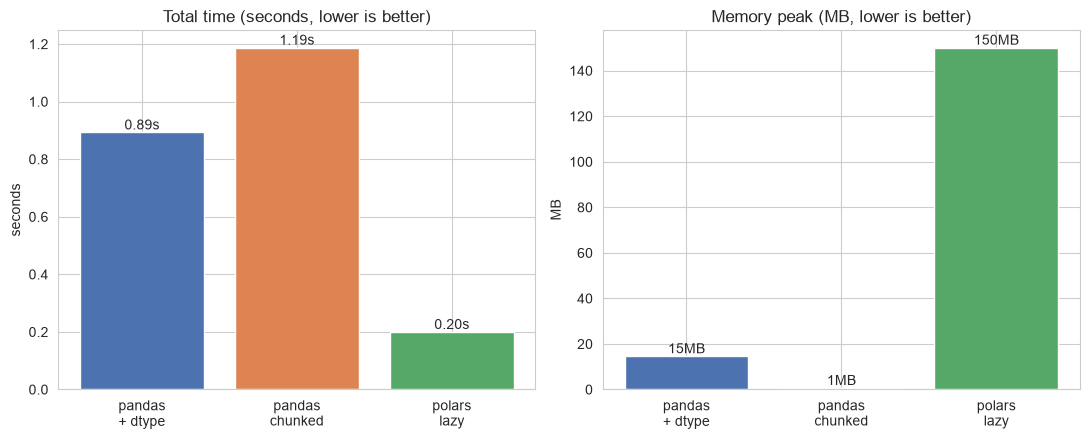

In [17]:
# ─────────────────────────────────────────────
# [도식] 세 가지 방식의 시간·메모리 비교
# ─────────────────────────────────────────────
methods = ["pandas\n+ dtype", "pandas\nchunked", "polars\nlazy"]
times = [elapsed_pd_full, elapsed_chunk_full, elapsed_pl_full]
peaks = [peak_pd_full, peak_chunk_full, peak_pl_full]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars0 = axes[0].bar(methods, times, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Total time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

bars1 = axes[1].bar(methods, peaks, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Memory peak (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()